# 03. Model Training

This notebook trains and compares four classification models 
to predict credit default (`SeriousDlqin2yrs`).

**Models covered:**
1. Logistic Regression (baseline)
2. Random Forest + RandomizedSearchCV tuning
3. XGBoost + RandomizedSearchCV tuning + Early Stopping
4. XGBoost + SMOTE

**Validation strategy:**
- RandomizedSearchCV uses 5-fold CV within the training set
- XGBoost early stopping uses the dedicated validation set
- Test set is used only once for final evaluation in `04_evaluation.ipynb`

## 1. Import Libraries & Load Processed Data

In [1]:
%pip install xgboost
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# File and metadata management
from pathlib import Path

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score, recall_score, f1_score
)

# Model persistence
import joblib

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Suppress warnings for cleaner output
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn
warnings.filterwarnings("ignore")

In [4]:
# Load processed data
data_path = Path("../data/processed")

X_train = pd.read_csv(data_path / "X_train.csv")
X_val   = pd.read_csv(data_path / "X_val.csv")
X_test  = pd.read_csv(data_path / "X_test.csv")
y_train = pd.read_csv(data_path / "y_train.csv").squeeze()
y_val   = pd.read_csv(data_path / "y_val.csv").squeeze()
y_test  = pd.read_csv(data_path / "y_test.csv").squeeze()

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Validation set : {X_val.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print("\nClass distribution — Training set:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

Training set   : 89,634 rows
Validation set : 29,878 rows
Test set       : 29,878 rows

Class distribution — Training set:
SeriousDlqin2yrs
0    93.3
1     6.7
Name: proportion, dtype: float64


## 2. Addressing Class Imbalance

The dataset is heavily imbalanced — only 6.7% of borrowers 
defaulted. If left unaddressed, models tend to predict the 
majority class (no default) for almost every case, achieving 
high accuracy but failing to identify actual defaulters.

**Strategy: `class_weight='balanced'`**  
This automatically adjusts the weight of each class inversely 
proportional to its frequency. The minority class (default = 1) 
is given higher weight, penalising the model more for missing 
a defaulter than for a false alarm.

This approach is applied to Logistic Regression and Random Forest. 
XGBoost uses the equivalent `scale_pos_weight` parameter.

In [5]:
# Calculate scale_pos_weight for XGBoost
# = number of negative cases / number of positive cases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative cases (no default): {neg}")
print(f"Positive cases (default):    {pos}")
print(f"scale_pos_weight:            {scale_pos_weight:.2f}")

Negative cases (no default): 83629
Positive cases (default):    6005
scale_pos_weight:            13.93


## 3. Model 1 — Logistic Regression (Baseline)

Logistic Regression is used as a **baseline model**. 

A baseline gives us a reference point — if a more complex model 
(Random Forest, XGBoost) cannot outperform logistic regression, 
it suggests the added complexity is not justified.

Logistic Regression is also highly interpretable — the 
coefficients directly indicate the direction and magnitude 
of each feature's effect on default probability.

In [6]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

# Predictions
lr_pred       = lr.predict(X_test)
lr_pred_proba = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression training complete.")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, lr_pred_proba):.4f}")

Logistic Regression training complete.

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.77      0.86     27876
           1       0.19      0.75      0.30      2002

    accuracy                           0.77     29878
   macro avg       0.58      0.76      0.58     29878
weighted avg       0.92      0.77      0.82     29878

AUC-ROC: 0.8376


## 4. Model 2 — Random Forest + Hyperparameter Tuning

Random Forest is an ensemble of decision trees trained on 
random subsets of data and features.

**Tuning strategy: RandomizedSearchCV with 5-fold CV**  
Rather than exhaustively testing all parameter combinations 
(GridSearchCV), RandomizedSearchCV samples `n_iter=30` random 
combinations — achieving comparable results in a fraction of 
the time.

The CV is performed entirely within the training set — 
the validation and test sets are not involved at this stage.

**Parameters tuned:**
- `n_estimators`: Number of trees
- `max_depth`: Maximum tree depth — controls overfitting
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required at a leaf node

In [7]:
# Define parameter search space
rf_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Running RandomizedSearchCV for Random Forest (n_iter=30)...")
rf_search.fit(X_train, y_train)

print(f"\nBest parameters: {rf_search.best_params_}")
print(f"Best CV AUC-ROC: {rf_search.best_score_:.4f}")

# Use best estimator
rf = rf_search.best_estimator_

# Predictions
rf_pred       = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, rf_pred))
print(f"Test AUC-ROC: {roc_auc_score(y_test, rf_pred_proba):.4f}")

Running RandomizedSearchCV for Random Forest (n_iter=30)...

Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Best CV AUC-ROC: 0.8571

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27876
           1       0.23      0.73      0.36      2002

    accuracy                           0.82     29878
   macro avg       0.61      0.78      0.63     29878
weighted avg       0.93      0.82      0.86     29878

Test AUC-ROC: 0.8602


## 5. Model 3 — XGBoost + Hyperparameter Tuning + Early Stopping

XGBoost builds trees sequentially — each tree corrects errors 
from the previous one (gradient boosting).

**Two-stage tuning approach:**

**Stage 1 — RandomizedSearchCV (5-fold CV in train set)**  
Finds the best combination of learning rate, tree depth, 
and regularisation parameters.

**Stage 2 — Early Stopping (validation set)**  
Using the best parameters from Stage 1, XGBoost is retrained 
with `early_stopping_rounds=50`. Training halts when AUC on 
the validation set stops improving — preventing overfitting 
and automatically selecting the optimal `n_estimators`.

**Why early stopping needs a separate val set (not CV):**  
Early stopping monitors a single held-out set sequentially 
across boosting rounds. Cross-validation folds are independent 
evaluations and cannot serve this monitoring role.

In [9]:
# ── Stage 1: RandomizedSearchCV ─────────────────────────────
xgb_param_dist = {
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1, 1.5, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        n_estimators=300,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Running RandomizedSearchCV for XGBoost (n_iter=30)...")
xgb_search.fit(X_train, y_train)
best_params = xgb_search.best_params_

print(f"\nBest parameters: {best_params}")
print(f"Best CV AUC-ROC: {xgb_search.best_score_:.4f}")

# ── Stage 2: Retrain with early stopping ─────────────────────
print("\nRetraining with best parameters + early stopping...")

xgb = XGBClassifier(
    **best_params,
    n_estimators=1000,          # high ceiling — early stopping decides
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  # val set used here — NOT test set
    verbose=False
)

print(f"Best iteration (early stopping): {xgb.best_iteration}")
print(f"Best validation AUC-ROC       : {xgb.best_score:.4f}")

# Predictions on test set
xgb_pred       = xgb.predict(X_test)
xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, xgb_pred))
print(f"Test AUC-ROC: {roc_auc_score(y_test, xgb_pred_proba):.4f}")

Running RandomizedSearchCV for XGBoost (n_iter=30)...

Best parameters: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV AUC-ROC: 0.8642

Retraining with best parameters + early stopping...
Best iteration (early stopping): 305
Best validation AUC-ROC       : 0.8659

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27876
           1       0.22      0.79      0.34      2002

    accuracy                           0.79     29878
   macro avg       0.60      0.79      0.61     29878
weighted avg       0.93      0.79      0.84     29878

Test AUC-ROC: 0.8662


## 6. Model 4 — XGBoost + SMOTE

SMOTE (Synthetic Minority Oversampling Technique) generates 
synthetic samples of the minority class to balance the training 
set before fitting XGBoost.

**Note:** SMOTE is applied only to the training set — never to 
the validation or test sets. Oversampling held-out data would 
introduce data leakage and inflate performance metrics.

This model uses the same best hyperparameters found in Stage 1 
of the XGBoost tuning above, without early stopping (SMOTE 
addresses class imbalance directly, removing the need for 
`scale_pos_weight`).

In [11]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

xgb_sm = XGBClassifier(
    **best_params, 
    n_estimators=xgb.best_iteration,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_sm.fit(X_train_sm, y_train_sm)
xgb_sm_proba = xgb_sm.predict_proba(X_test)[:, 1]
xgb_sm_pred  = xgb_sm.predict(X_test)

print(f"\nXGBoost + SMOTE AUC-ROC: {roc_auc_score(y_test, xgb_sm_proba):.4f}")
print(classification_report(y_test, xgb_sm_pred))

Before SMOTE: {0: 83629, 1: 6005}
After SMOTE:  {0: 83629, 1: 83629}

XGBoost + SMOTE AUC-ROC: 0.8580
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27876
           1       0.36      0.51      0.42      2002

    accuracy                           0.91     29878
   macro avg       0.66      0.72      0.69     29878
weighted avg       0.92      0.91      0.91     29878



## 7. Model Comparison

All four models are compared on the test set using:

- **AUC-ROC**: Overall discrimination ability across all thresholds
- **AUC-PR**: More honest metric for imbalanced datasets — focuses 
  on minority class performance
- **Precision**: Of predicted defaulters, how many truly defaulted?
- **Recall**: Of actual defaulters, how many did the model catch?
- **F1-Score**: Harmonic mean of Precision and Recall

**Important:** These are test set results. The validation set 
was used only for XGBoost early stopping and is not evaluated here.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Logistic Regression': (lr_pred, lr_pred_proba),
    'Random Forest':       (rf_pred, rf_pred_proba),
    'XGBoost':             (xgb_pred, xgb_pred_proba),
    'XGBoost + SMOTE':     (xgb_sm_pred, xgb_sm_proba)
}

results = []
for name, (pred, proba) in models.items():
    results.append({
        'Model':     name,
        'AUC-ROC':   round(roc_auc_score(y_test, proba), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1-Score':  round(f1_score(y_test, pred), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

                     AUC-ROC  Precision  Recall  F1-Score
Model                                                    
Logistic Regression   0.8376     0.1895  0.7532    0.3028
Random Forest         0.8602     0.2345  0.7313    0.3552
XGBoost               0.8662     0.2152  0.7852    0.3378
XGBoost + SMOTE       0.8580     0.3648  0.5080    0.4246


### Threshold Analysis

To determine the optimal classification threshold, we evaluated
Precision, Recall, and F1-Score across multiple thresholds
for the XGBoost model.

The default threshold of **0.5 yields the best F1-Score (0.3378)**
and is retained. Lower thresholds increase Recall but significantly
reduce Precision, resulting in too many false alarms to be
practically useful.

In [18]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for thresh in thresholds:
    pred = (xgb_pred_proba >= thresh).astype(int)
    p = precision_score(y_test, pred)
    r = recall_score(y_test, pred)
    f = f1_score(y_test, pred)
    print(f"{thresh:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.1          0.0819       0.9795       0.1512      
0.2          0.1158       0.9371       0.2061      
0.3          0.1469       0.8916       0.2523      
0.4          0.1773       0.8497       0.2933      
0.5          0.2152       0.7852       0.3378      


## 8. ROC Curve Comparison

The ROC curve plots True Positive Rate against False Positive 
Rate at every classification threshold.

Note: Given the 6.7% class imbalance, ROC curves may present 
an optimistic view. A Precision-Recall curve analysis is 
conducted in `04_evaluation.ipynb` for a more complete picture.

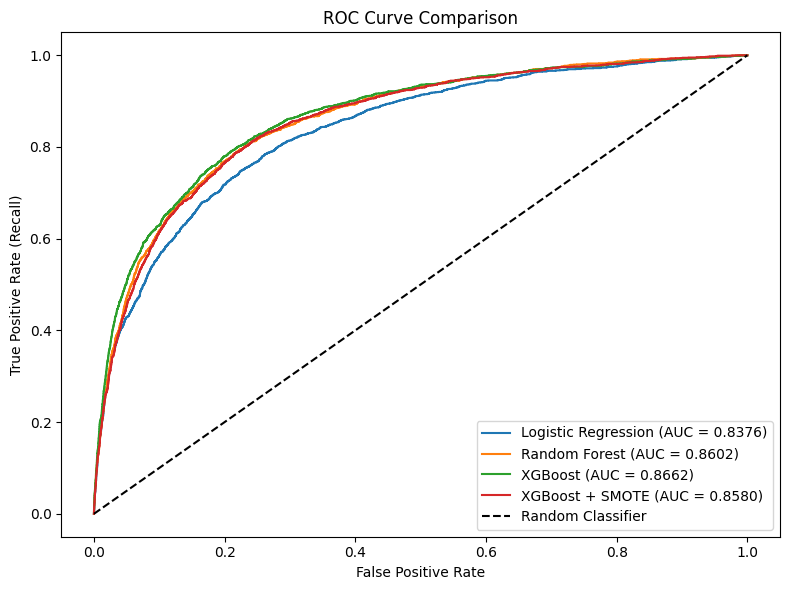

In [15]:
plt.figure(figsize=(8, 6))

for name, (pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Feature Importance — Random Forest & XGBoost

Feature importance reveals which variables contribute most 
to each model's predictions, translating model behaviour 
into actionable business insights.

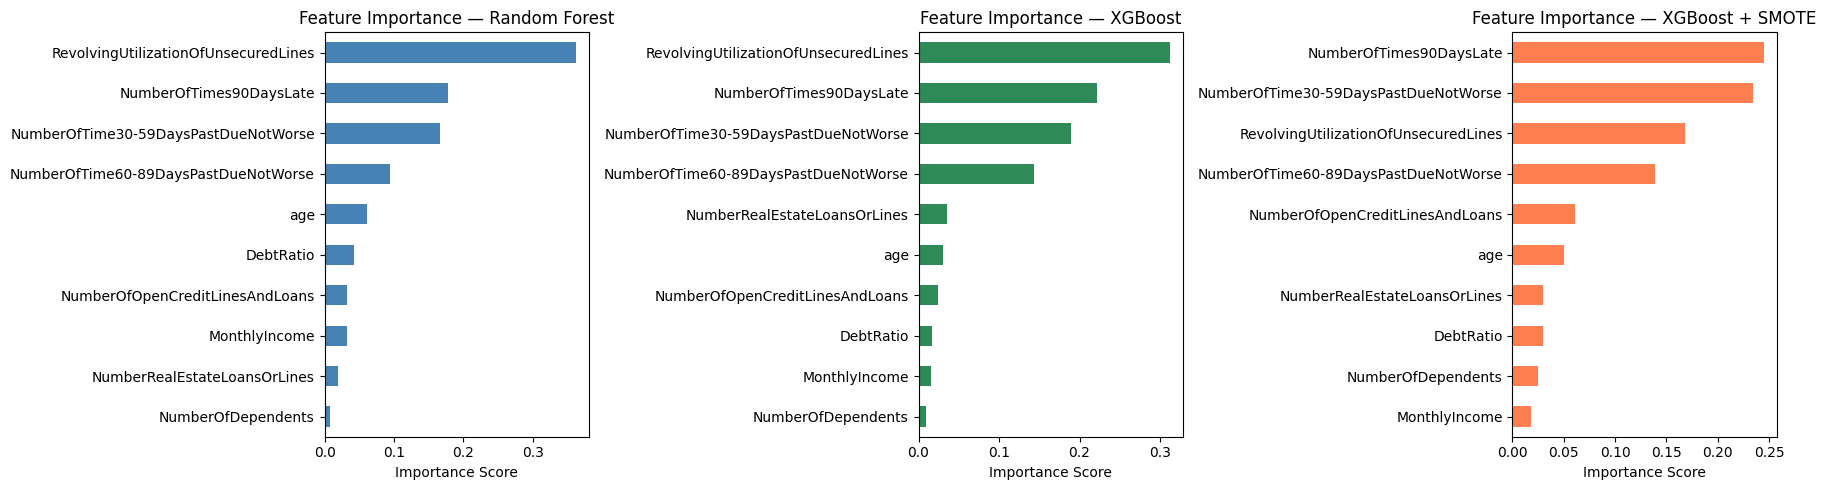

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest feature importance
rf_importance = pd.Series(
    rf.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)

rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_xlabel('Importance Score')

# XGBoost feature importance
xgb_importance = pd.Series(
    xgb.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)

xgb_importance.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Feature Importance — XGBoost')
axes[1].set_xlabel('Importance Score')

# XGBoost + SMOTE feature importance
xgb_sm_importance = pd.Series(
    xgb_sm.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)

xgb_sm_importance.plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Feature Importance — XGBoost + SMOTE')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 10. Save Models

All trained models are saved using `joblib` for use 
in the evaluation notebook and potential future deployment.

In [17]:
model_path = Path("../outputs/models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(lr,     model_path / "logistic_regression.pkl")
joblib.dump(rf,     model_path / "random_forest.pkl")
joblib.dump(xgb,    model_path / "xgboost.pkl")
joblib.dump(xgb_sm, model_path / "xgboost_smote.pkl")

print("Models saved to ../outputs/models/")
print("  - logistic_regression.pkl")
print("  - random_forest.pkl")
print("  - xgboost.pkl")
print("  - xgboost_smote.pkl")

Models saved to ../outputs/models/
  - logistic_regression.pkl
  - random_forest.pkl
  - xgboost.pkl
  - xgboost_smote.pkl


## 11. Modeling Summary

| Model | AUC-ROC | Precision | Recall | F1-Score | Tuning |
|---|---|---|---|---|---|
| Logistic Regression | 0.8376 | 0.1895 | 0.7532 | 0.3028 | None (baseline) |
| Random Forest | 0.8602 | 0.2345 | 0.7313 | 0.3552 | RandomizedSearchCV (n_iter=30) |
| **XGBoost** ✅ | **0.8662** | 0.2152 | **0.7852** | 0.3378 | RandomizedSearchCV + Early Stopping |
| XGBoost + SMOTE | 0.8580 | 0.3648 | 0.5080 | 0.4246 | Best XGBoost params |

**Best parameters found:**
- Random Forest: `n_estimators=300, min_samples_split=10, min_samples_leaf=4, max_depth=10`
- XGBoost: `subsample=0.9, reg_lambda=1, reg_alpha=0.1, max_depth=3, learning_rate=0.05, colsample_bytree=0.9`
- XGBoost best iteration (early stopping): 305

**Key improvements over Logistic Regression baseline:**
- Random Forest and XGBoost both achieve higher AUC-ROC (+0.023, +0.029) 
  — tree-based models better capture non-linear relationships in credit data
- XGBoost achieves the best balance of AUC-ROC (0.8662) and Recall (0.7852), 
  catching a comparable number of defaulters as LR while improving overall discrimination

**Why SMOTE underperforms on this dataset:**
SMOTE generates synthetic minority samples by interpolating between 
existing defaulters in feature space. However, several features are 
discrete count variables (e.g. `NumberOfTimes90DaysLate`, 
`NumberOfTime30-59DaysPastDueNotWorse`) — interpolating between 
integer counts produces unrealistic synthetic samples that introduce 
noise rather than useful signal. This explains why `scale_pos_weight` 
outperforms SMOTE here.

Detailed evaluation and business recommendations are covered 
in `04_evaluation.ipynb`.